# Preprocessing dữ liệu ảnh phân loại rác

Notebook này thực hiện đầy đủ các bước tiền xử lý cho bài toán phân loại ảnh rác:

1. Cấu hình đường dẫn và tham số chung.
2. Quét ảnh từ dataset, kiểm tra ảnh lỗi/hỏng.
3. Thống kê số lượng ảnh theo từng lớp.
4. Chia `Train` thành `train` và `validation`, giữ nguyên split `Test` gốc.
5. Tạo pipeline transform: resize, augmentation, chuyển tensor, normalize.
6. Tạo `Dataset` và `DataLoader` cho PyTorch.
7. Tính class weights để xử lý lệch lớp khi train.
8. Lưu metadata đã xử lý ra file CSV/JSON.

In [14]:
# Import các thư viện cần dùng cho preprocessing.
# pathlib: xử lý đường dẫn theo cách an toàn trên Windows/Linux/Mac.
# pandas/numpy: lưu metadata và thống kê dữ liệu.
# PIL: đọc và kiểm tra ảnh.
# sklearn: chia tập train/validation có stratify theo nhãn.
# torch/torchvision: xây Dataset, DataLoader và transform ảnh.

from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# Giúp kết quả chia dữ liệu và augmentation có thể tái lập tương đối.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Nếu máy có GPU CUDA, PyTorch sẽ dùng GPU trong các bước train sau này.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

## 1. Cấu hình đường dẫn

Dataset sau khi tải bằng `src/download_data.py` thường nằm ở `data/VN_trash_classification` và có hai thư mục con `Train`, `Test`.

In [2]:
# ROOT_DIR là thư mục gốc của project. Vì notebook nằm trong thư mục eda,
# ta dùng Path.cwd() và kiểm tra thêm parent để chạy được cả khi mở notebook
# từ thư mục gốc hoặc từ chính thư mục eda.

CURRENT_DIR = Path.cwd()
ROOT_DIR = CURRENT_DIR if (CURRENT_DIR / "data").exists() else CURRENT_DIR.parent
DATA_DIR = ROOT_DIR / "data"
DATASET_DIR = DATA_DIR / "VN_trash_classification"
TRAIN_DIR = DATASET_DIR / "Train"
TEST_DIR = DATASET_DIR / "Test"

# Thư mục lưu metadata sau preprocessing.
PROCESSED_DIR = DATA_DIR / "processed_metadata"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Các định dạng ảnh hợp lệ sẽ được đưa vào dataset.
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Tham số transform. 224x224 phù hợp với nhiều CNN pretrained như ResNet/EfficientNet.
IMAGE_SIZE = 224
BATCH_SIZE = 32
VALIDATION_SIZE = 0.15
NUM_WORKERS = 0  # Trên Windows/Jupyter để 0 thường ổn định hơn.

print("Root dir:", ROOT_DIR)
print("Dataset dir:", DATASET_DIR)
print("Train exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())

Root dir: c:\Users\XPS\Desktop\trash-image-classification
Dataset dir: c:\Users\XPS\Desktop\trash-image-classification\data\VN_trash_classification
Train exists: True
Test exists: True


## 2. Quét ảnh và kiểm tra ảnh lỗi

Mỗi lớp được lấy từ tên thư mục cha của ảnh, ví dụ `Train/Alu/...jpg` có nhãn là `Alu`.

In [3]:
def collect_images(split_dir: Path, split_name: str) -> tuple[pd.DataFrame, list[dict]]:
    """Quét toàn bộ ảnh trong một split và bỏ qua ảnh không đọc được."""
    records = []
    bad_files = []

    # rglob('*') duyệt đệ quy mọi file con để notebook vẫn chạy được
    # nếu dataset có thêm thư mục con ngoài cấu trúc class trực tiếp.
    for image_path in sorted(split_dir.rglob("*")):
        if not image_path.is_file():
            continue

        # Bỏ qua file không phải ảnh theo phần mở rộng.
        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        # verify() giúp phát hiện ảnh bị hỏng trước khi đưa vào training.
        try:
            with Image.open(image_path) as image:
                image.verify()
        except (UnidentifiedImageError, OSError) as error:
            bad_files.append({"path": str(image_path), "error": str(error)})
            continue

        records.append(
            {
                "path": str(image_path),
                "label": image_path.parent.name,
                "original_split": split_name,
            }
        )

    dataframe = pd.DataFrame(records, columns=["path", "label", "original_split"])
    return dataframe, bad_files


train_full_df, bad_train_files = collect_images(TRAIN_DIR, "train")
test_df, bad_test_files = collect_images(TEST_DIR, "test")

print("Số ảnh train gốc:", len(train_full_df))
print("Số ảnh test gốc:", len(test_df))
print("Số ảnh lỗi train:", len(bad_train_files))
print("Số ảnh lỗi test:", len(bad_test_files))

train_full_df.head()

Số ảnh train gốc: 11227
Số ảnh test gốc: 864
Số ảnh lỗi train: 0
Số ảnh lỗi test: 0


,path,label,original_split
0,c:\Users\XPS\Desktop\trash-image-classificatio...,Alu,train
1,c:\Users\XPS\Desktop\trash-image-classificatio...,Alu,train
2,c:\Users\XPS\Desktop\trash-image-classificatio...,Alu,train
3,c:\Users\XPS\Desktop\trash-image-classificatio...,Alu,train
4,c:\Users\XPS\Desktop\trash-image-classificatio...,Alu,train


In [4]:
# Lưu danh sách ảnh lỗi để có thể kiểm tra lại thủ công nếu cần.
bad_files = bad_train_files + bad_test_files
if bad_files:
    bad_files_df = pd.DataFrame(bad_files)
    bad_files_df.to_csv(PROCESSED_DIR / "bad_images.csv", index=False)
    display(bad_files_df.head())
else:
    print("Không phát hiện ảnh lỗi/hỏng.")

Không phát hiện ảnh lỗi/hỏng.


## 3. Thống kê phân bố lớp

Bước này giúp kiểm tra dataset có bị lệch lớp mạnh không, từ đó quyết định dùng class weights hoặc sampler khi train.

,original_split,label,count
0,test,Alu,99
1,test,Carton,108
2,test,Foam_box,87
3,test,Milk_box,101
4,test,Other,50
5,test,PET,102
6,test,Paper,106
7,test,Paper_cup,105
8,test,Plastic_cup,106
9,train,Alu,1246


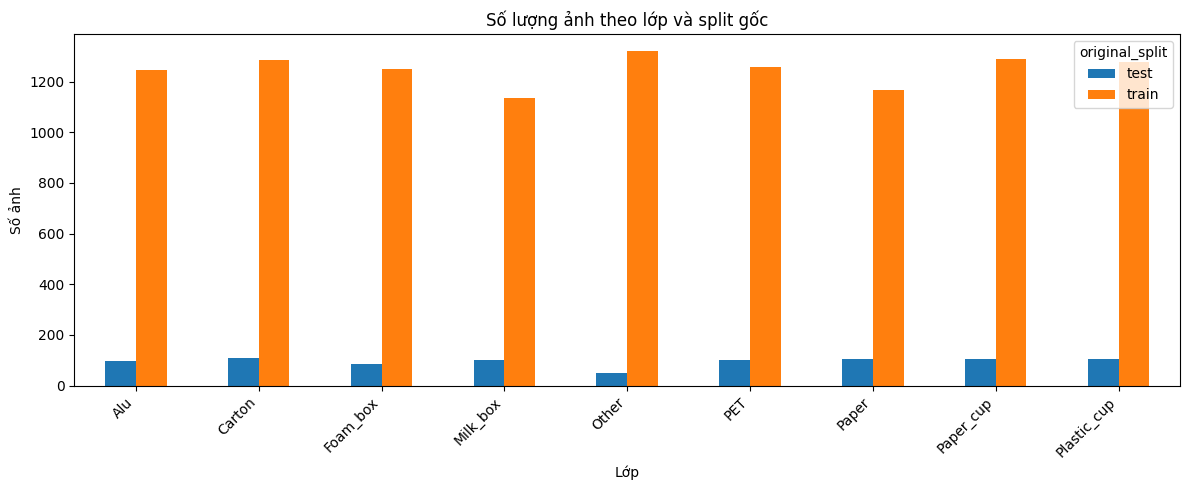

In [5]:
# Ghép train gốc và test để xem tổng quan số lượng ảnh theo split/lớp.
all_raw_df = pd.concat([train_full_df, test_df], ignore_index=True)

class_counts = (
    all_raw_df.groupby(["original_split", "label"])
    .size()
    .reset_index(name="count")
    .sort_values(["original_split", "label"])
)

display(class_counts)

pivot_counts = class_counts.pivot(index="label", columns="original_split", values="count").fillna(0)
pivot_counts.plot(kind="bar", figsize=(12, 5))
plt.title("Số lượng ảnh theo lớp và split gốc")
plt.xlabel("Lớp")
plt.ylabel("Số ảnh")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Tạo mapping nhãn và chia train/validation

Ta giữ nguyên `Test` để đánh giá cuối cùng. Từ `Train` gốc, tách `validation` theo tỉ lệ `VALIDATION_SIZE` và dùng `stratify` để mỗi lớp vẫn có phân bố tương đối đều.

In [20]:
# Kiểm tra dữ liệu trước khi split để báo lỗi rõ ràng nếu thiếu ảnh/lớp.
if train_full_df.empty:
    raise ValueError("Không tìm thấy ảnh trong thư mục Train.")
if test_df.empty:
    raise ValueError("Không tìm thấy ảnh trong thư mục Test.")

min_class_count = train_full_df["label"].value_counts().min()
if min_class_count < 2:
    raise ValueError("Mỗi lớp trong Train cần ít nhất 2 ảnh để chia validation có stratify.")

# Tạo class_to_idx cố định theo thứ tự alphabet để label id ổn định giữa các lần chạy.
classes = sorted(train_full_df["label"].unique())
class_to_idx = {class_name: idx for idx, class_name in enumerate(classes)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

# Stratified split giữ tỉ lệ lớp giữa train và validation.
train_df, validation_df = train_test_split(
    train_full_df,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_SEED,
    stratify=train_full_df["label"],
)

# Reset index giúp Dataset truy cập bằng iloc[index] không bị lệch chỉ số.
train_df = train_df.reset_index(drop=True).assign(split="train")
validation_df = validation_df.reset_index(drop=True).assign(split="validation")
test_df = test_df.reset_index(drop=True).assign(split="test")

# Kiểm tra rò rỉ: một file ảnh không được xuất hiện ở nhiều split.
train_paths = set(train_df["path"])
validation_paths = set(validation_df["path"])
test_paths = set(test_df["path"])
assert train_paths.isdisjoint(validation_paths), "Phát hiện ảnh bị trùng giữa train và validation."
assert train_paths.isdisjoint(test_paths), "Phát hiện ảnh bị trùng giữa train và test."
assert validation_paths.isdisjoint(test_paths), "Phát hiện ảnh bị trùng giữa validation và test."
print("Data leakage check: PASS")

print("Classes:", class_to_idx)
print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Data leakage check: PASS
Classes: {'Alu': 0, 'Carton': 1, 'Foam_box': 2, 'Milk_box': 3, 'Other': 4, 'PET': 5, 'Paper': 6, 'Paper_cup': 7, 'Plastic_cup': 8}
Train: 9542
Validation: 1685
Test: 864


In [23]:
# Xem tổng số ảnh, số lớp và phân bố lớp sau khi chia train/validation/test.
split_df = pd.concat([train_df, validation_df, test_df], ignore_index=True)
split_counts = split_df.groupby(["split", "label"]).size().reset_index(name="count")

split_summary = (
    split_df.groupby("split")
    .agg(Images=("path", "count"), Classes=("label", "nunique"))
    .reindex(["train", "validation", "test"])
)
print("Thống kê tổng quan sau khi chia:")
display(split_summary)

print("Số lượng từng lớp trong mỗi split:")
display(
    split_counts
    .pivot(index="label", columns="split", values="count")
    .reindex(columns=["train", "validation", "test"])
    .fillna(0)
    .astype(int)
)

Thống kê tổng quan sau khi chia:


,Images,Classes
split,,
train,9542,9
validation,1685,9
test,864,9


Số lượng từng lớp trong mỗi split:


split,train,validation,test
label,,,
Alu,1059,187,99
Carton,1093,193,108
Foam_box,1061,187,87
Milk_box,965,170,101
Other,1124,198,50
PET,1069,189,102
Paper,992,175,106
Paper_cup,1095,194,105
Plastic_cup,1084,192,106


## 5. Transform ảnh

- `RandomHorizontalFlip`: tạo thêm biến thể theo hướng nhìn, giúp mô hình tổng quát tốt hơn.
- `RandomResizedCrop`: mô phỏng thay đổi góc chụp, khoảng cách và vùng quan sát đối tượng.
- `RandomRotation`: tăng khả năng chịu được ảnh bị nghiêng nhẹ.
- `ColorJitter`: mô phỏng thay đổi ánh sáng, độ tương phản và màu sắc.
- Validation/Test không dùng augmentation ngẫu nhiên để kết quả đánh giá ổn định.
- Mean/std dùng chuẩn ImageNet vì phù hợp với nhiều CNN pretrained.

In [15]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# Pipeline dành cho training: có augmentation để tăng độ đa dạng dữ liệu.
train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

# Pipeline dành cho validation/test: không có bước ngẫu nhiên để kết quả đánh giá nhất quán.
eval_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

## 6. Tạo Dataset và DataLoader

In [16]:
class TrashDataset(Dataset):

    def __init__(self, dataframe: pd.DataFrame, class_to_idx: dict[str, int], transform=None):
        # Copy/reset index để Dataset không phụ thuộc vào index cũ sau khi split.
        self.dataframe = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index: int):
        # Lấy một dòng metadata gồm path và label.
        row = self.dataframe.iloc[index]

        # convert('RGB') đảm bảo ảnh luôn có 3 kênh màu, kể cả ảnh gốc là grayscale/RGBA.
        with Image.open(row["path"]) as image:
            image = image.convert("RGB")

        # Áp dụng transform tương ứng với split.
        if self.transform is not None:
            image = self.transform(image)

        # Chuyển nhãn dạng chuỗi sang id số để dùng với CrossEntropyLoss.
        label = self.class_to_idx[row["label"]]
        return image, label


train_dataset = TrashDataset(train_df, class_to_idx, train_transform)
validation_dataset = TrashDataset(validation_df, class_to_idx, eval_transform)
test_dataset = TrashDataset(test_df, class_to_idx, eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Số batch train:", len(train_loader))
print("Số batch validation:", len(validation_loader))
print("Số batch test:", len(test_loader))

Số batch train: 299
Số batch validation: 53
Số batch test: 27


In [21]:
# Kiểm tra nhanh một batch để chắc chắn shape đúng: [batch_size, channels, height, width].
images, labels = next(iter(train_loader))
print("Batch size:", images.shape[0])
print("Number of batches - train:", len(train_loader))
print("Number of batches - validation:", len(validation_loader))
print("Number of batches - test:", len(test_loader))
print("Input shape:", tuple(images.shape[1:]))
print("Number of classes:", len(class_to_idx))
print("Label batch shape:", labels.shape)
print("Min pixel sau normalize:", images.min().item())
print("Max pixel sau normalize:", images.max().item())

Batch size: 32
Number of batches - train: 299
Number of batches - validation: 53
Number of batches - test: 27
Input shape: (3, 224, 224)
Number of classes: 9
Label batch shape: torch.Size([32])
Min pixel sau normalize: -2.1179039478302
Max pixel sau normalize: 2.640000104904175


## 7. Hiển thị ảnh sau transform

Ảnh đã normalize cần được unnormalize trước khi hiển thị, nếu không màu sẽ bị sai.

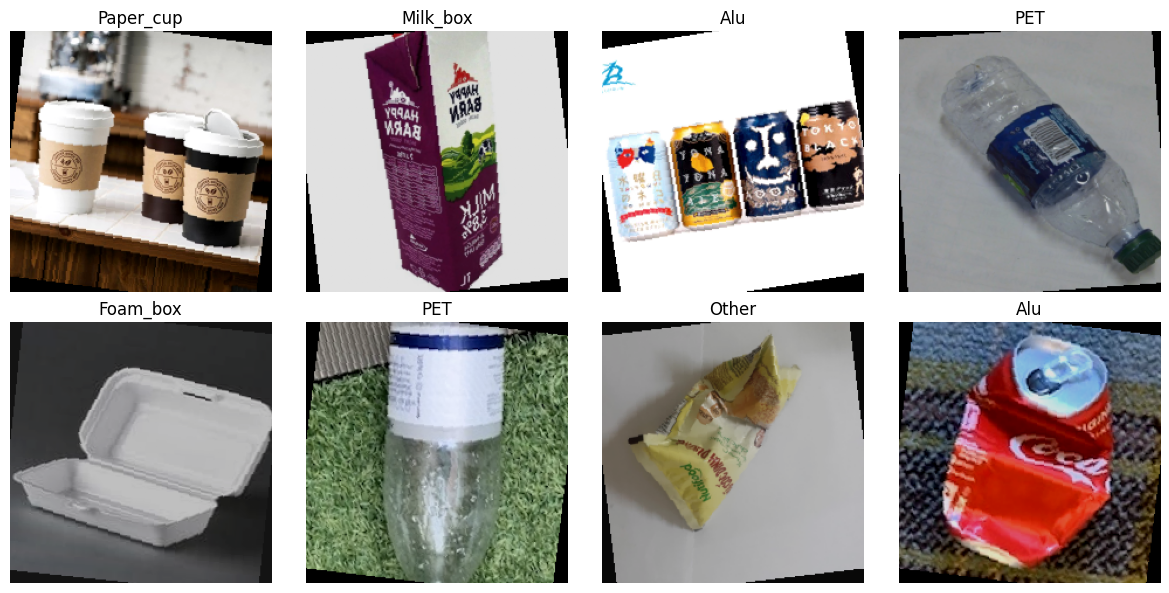

In [11]:
def denormalize(image_tensor: torch.Tensor) -> np.ndarray:
    """Đưa tensor đã normalize về ảnh numpy trong khoảng [0, 1] để hiển thị."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image_tensor = image_tensor.cpu() * std + mean
    image_tensor = image_tensor.clamp(0, 1)
    return image_tensor.permute(1, 2, 0).numpy()


plt.figure(figsize=(12, 6))
for idx in range(min(8, len(images))):
    plt.subplot(2, 4, idx + 1)
    plt.imshow(denormalize(images[idx]))
    plt.title(idx_to_class[int(labels[idx])])
    plt.axis("off")
plt.tight_layout()
plt.show()

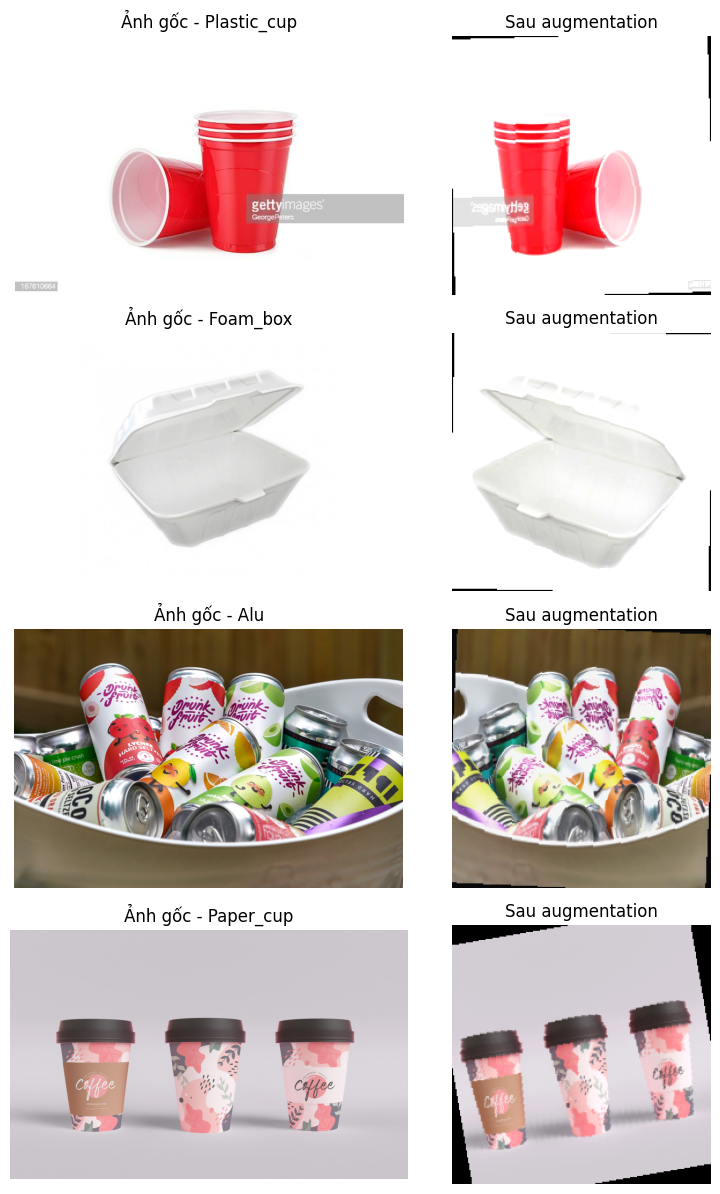

In [22]:
# So sánh ảnh gốc và ảnh sau augmentation trên cùng một số mẫu.
comparison_rows = train_df.head(4)
fig, axes = plt.subplots(len(comparison_rows), 2, figsize=(8, 3 * len(comparison_rows)))

for row_index, (_, row) in enumerate(comparison_rows.iterrows()):
    with Image.open(row["path"]) as original_image:
        original_image = original_image.convert("RGB")
        augmented_tensor = train_transform(original_image)
        augmented_image = denormalize(augmented_tensor)

        axes[row_index, 0].imshow(original_image)
        axes[row_index, 0].set_title(f"Ảnh gốc - {row['label']}")
        axes[row_index, 1].imshow(augmented_image)
        axes[row_index, 1].set_title("Sau augmentation")

    axes[row_index, 0].axis("off")
    axes[row_index, 1].axis("off")

plt.tight_layout()
plt.show()

## 8. Tính class weights

Class weights có thể truyền vào `torch.nn.CrossEntropyLoss(weight=class_weights)` để giảm ảnh hưởng của lệch lớp.

Lớp có ít mẫu sẽ nhận trọng số lớn hơn, nhờ đó giảm ảnh hưởng của mất cân bằng dữ liệu trong quá trình huấn luyện.

In [24]:
def compute_class_weights(labels: pd.Series, class_to_idx: dict[str, int]) -> torch.Tensor:
    """Tính trọng số nghịch đảo tần suất cho từng lớp."""
    label_ids = labels.map(class_to_idx)
    counts = label_ids.value_counts().reindex(range(len(class_to_idx)), fill_value=0)

    if (counts == 0).any():
        raise ValueError("Mỗi lớp phải xuất hiện trong train split để tính class weights.")

    # Công thức: tổng số mẫu / (số lớp * số mẫu của lớp đó).
    # Lớp ít ảnh hơn sẽ có weight lớn hơn.
    weights = len(labels) / (len(class_to_idx) * counts.to_numpy(dtype=float))
    return torch.tensor(weights, dtype=torch.float32)


class_weights = compute_class_weights(train_df["label"], class_to_idx).to(DEVICE)
print("Class weights:", class_weights)

Class weights: tensor([1.0012, 0.9700, 0.9993, 1.0987, 0.9433, 0.9918, 1.0688, 0.9682, 0.9781])


## 9. Lưu metadata sau preprocessing

Các file này giúp bước train dùng lại split cố định, không bị thay đổi ngẫu nhiên ở mỗi lần chạy.

In [25]:
# Lưu từng split thành CSV để model training đọc lại dễ dàng.
train_df.to_csv(PROCESSED_DIR / "train.csv", index=False)
validation_df.to_csv(PROCESSED_DIR / "validation.csv", index=False)
test_df.to_csv(PROCESSED_DIR / "test.csv", index=False)

# Lưu mapping label <-> id để inference và evaluation dùng đúng thứ tự lớp.
with open(PROCESSED_DIR / "class_to_idx.json", "w", encoding="utf-8") as file:
    json.dump(class_to_idx, file, ensure_ascii=False, indent=2)

# Lưu class weights để bước train có thể nạp lại nếu muốn.
weights_payload = {idx_to_class[idx]: float(weight) for idx, weight in enumerate(class_weights.cpu())}
with open(PROCESSED_DIR / "class_weights.json", "w", encoding="utf-8") as file:
    json.dump(weights_payload, file, ensure_ascii=False, indent=2)

print("Đã lưu metadata vào:", PROCESSED_DIR)

Đã lưu metadata vào: c:\Users\XPS\Desktop\trash-image-classification\data\processed_metadata


## 10. Gợi ý dùng trong bước train

Sau notebook này, phần train có thể dùng trực tiếp `train_loader`, `validation_loader`, `test_loader`, `class_to_idx` và `class_weights`. Nếu train trong file `.py`, có thể chuyển các hàm `collect_images`, `TrashDataset`, `compute_class_weights` sang module `src/preprocessing.py` hoặc import module đã có sẵn.